[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_2_Multiple_Keys.ipynb)

# 09.2: Multiple Groupby Keys and the MultiIndex

In notebook 09.1 you answered "what is the mean life expectancy in each continent in 2007?" with a single-key groupby. But the Gapminder data spans 55 years, and the interesting question is not just where each continent stands today but how it got there. Answering that requires grouping by continent AND year simultaneously.

This notebook introduces multi-key groupby, explains the MultiIndex structure it produces, and shows two ways to work with that result: flattening it with `reset_index()` and pivoting it into a wide table with `unstack()`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


## The limit of a single groupby key

A groupby on `continent` alone collapses all 12 years into one number per continent. That answers the snapshot question but throws away the time dimension entirely.

In [2]:
# This loses the time dimension: one row per continent, averaging over all 55 years
df.groupby("continent")["lifeExp"].mean().round(1)

continent
Africa      48.9
Americas    64.7
Asia        60.1
Europe      71.9
Oceania     74.3
Name: lifeExp, dtype: float64

These numbers mix 1952 and 2007 together. Africa's mean of 48.9 is the average of 1952's 39.1 and 2007's 54.8 — two very different situations blended into one meaningless number. To preserve the time dimension, year has to be a grouping key, not something we average over.

## Groupby with multiple keys

Passing a list of column names to `groupby()` creates one group for every unique combination of those columns. The result is indexed by all the grouping keys together.

In [3]:
result = df.groupby(["continent", "year"])["lifeExp"].mean().round(1)
print(type(result))
print(result)

<class 'pandas.Series'>
continent  year
Africa     1952    39.1
           1957    41.3
           1962    43.3
           1967    45.3
           1972    47.5
           1977    49.6
           1982    51.6
           1987    53.3
           1992    53.6
           1997    53.6
           2002    53.3
           2007    54.8
Americas   1952    53.3
           1957    56.0
           1962    58.4
           1967    60.4
           1972    62.4
           1977    64.4
           1982    66.2
           1987    68.1
           1992    69.6
           1997    71.2
           2002    72.4
           2007    73.6
Asia       1952    46.3
           1957    49.3
           1962    51.6
           1967    54.7
           1972    57.3
           1977    59.6
           1982    62.6
           1987    64.9
           1992    66.5
           1997    68.0
           2002    69.2
           2007    70.7
Europe     1952    64.4
           1957    66.7
           1962    68.5
           1967    69.7


The result is a Series with a **MultiIndex** — a hierarchical index where each row is identified by a `(continent, year)` pair. The first level of the index is `continent`; the second level is `year`. This is the natural output when you group by two keys: you have one value per unique combination of those keys.

Reading the MultiIndex takes a moment to get used to. The continent name appears only once at the top of each continent block, not on every row. Each year appears indented below it.

## Accessing data in a MultiIndex

You can slice a MultiIndex Series with `.loc[]` using a tuple for the outer and inner level.

In [4]:
# All years for Africa
print("Africa:")
print(result.loc["Africa"])
print()

# A specific (continent, year) pair
print("Africa in 2007:", result.loc[("Africa", 2007)])

Africa:
year
1952    39.1
1957    41.3
1962    43.3
1967    45.3
1972    47.5
1977    49.6
1982    51.6
1987    53.3
1992    53.6
1997    53.6
2002    53.3
2007    54.8
Name: lifeExp, dtype: float64

Africa in 2007: 54.8


`.loc["Africa"]` returns all years for Africa as a plain Series, dropping one level of the index. `.loc[("Africa", 2007)]` retrieves the single value for that exact combination. Both patterns work for DataFrames with MultiIndex as well as Series.

## `reset_index()`: flattening the MultiIndex

A MultiIndex is useful for access and slicing, but most downstream operations — merging, filtering, plotting — are easier with a flat DataFrame where every index level is a regular column. `reset_index()` does that conversion.

In [5]:
flat = result.reset_index()
print(flat.dtypes)
flat.head(8)

continent        str
year           int64
lifeExp      float64
dtype: object


,continent,year,lifeExp
0,Africa,1952,39.1
1,Africa,1957,41.3
2,Africa,1962,43.3
3,Africa,1967,45.3
4,Africa,1972,47.5
5,Africa,1977,49.6
6,Africa,1982,51.6
7,Africa,1987,53.3


The MultiIndex levels are now ordinary columns. This is the form most commonly used after a multi-key groupby: one row per (continent, year) combination, with the aggregated value in its own column. Every seaborn chart, every merge, every subsequent filter operates naturally on this flat structure.

With the flat DataFrame, a line chart of life expectancy over time by continent is a single seaborn call.

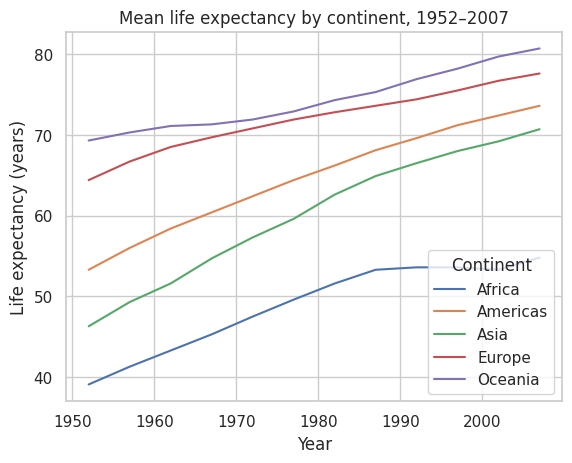

In [6]:
ax = sns.lineplot(
    data=flat,
    x="year", y="lifeExp",
    hue="continent"
)
ax.set_title("Mean life expectancy by continent, 1952–2007")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
ax.legend(title="Continent")

Every continent shows an upward trend over the 55 years, but the trajectories differ sharply. Europe and Oceania start high and continue rising steadily. Asia shows the steepest gain, driven largely by improvements in East and Southeast Asia. Africa rises through the 1980s, then flattens and dips in the 1990s — the period of the AIDS epidemic — before recovering slightly by 2007. The Americas follow a middle path between Asia and Europe.

This chart required the multi-key groupby. Without it, we had one number per continent with no time dimension to plot.

## `unstack()`: pivoting the MultiIndex into a wide table

The flat (long) format is best for charts. But sometimes you want the aggregated result as a wide table — one row per continent, one column per year — to read all the numbers at once. `unstack()` pivots one level of the MultiIndex into columns.

In [7]:
# Start from the MultiIndex Series (before reset_index)
wide = result.unstack("year")
wide.round(1)

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7


The wide table puts continents on the rows and years on the columns. You can now read across a row to see how a continent changed over time, or down a column to compare all continents in the same year. Africa's stagnation in the 1990s is visible directly in the column values.

`unstack("year")` specified which index level to pivot into columns. You could also call `unstack("continent")` to get the inverse arrangement: years as rows, continents as columns.

In [8]:
# Alternatively: years as rows, continents as columns
result.unstack("continent").round(1)

continent,Africa,Americas,Asia,Europe,Oceania
year,,,,,
1952,39.1,53.3,46.3,64.4,69.3
1957,41.3,56.0,49.3,66.7,70.3
1962,43.3,58.4,51.6,68.5,71.1
1967,45.3,60.4,54.7,69.7,71.3
1972,47.5,62.4,57.3,70.8,71.9
1977,49.6,64.4,59.6,71.9,72.9
1982,51.6,66.2,62.6,72.8,74.3
1987,53.3,68.1,64.9,73.6,75.3
1992,53.6,69.6,66.5,74.4,76.9


Either orientation contains the same data. The choice between them is purely about readability: use the one where the comparison you care about runs across a row or down a column. For comparing continents at a fixed point in time, continents as columns (years as rows) is more convenient.

## Groupby on a DataFrame, not just one column

So far we have selected one column after the groupby: `groupby(...)["lifeExp"]`. You can also aggregate multiple columns at once by selecting a list of columns or by not selecting any specific column at all.

In [9]:
# Mean of all numeric columns, grouped by continent and year
df.groupby(["continent", "year"])[["lifeExp", "gdpPercap"]].mean().round(1).head(12)

lifeExp  gdpPercap
continent year                    
Africa    1952     39.1     1252.6
          1957     41.3     1385.2
          1962     43.3     1598.1
          1967     45.3     2050.4
          1972     47.5     2339.6
          1977     49.6     2585.9
          1982     51.6     2481.6
          1987     53.3     2282.7
          1992     53.6     2281.8
          1997     53.6     2378.8
          2002     53.3     2599.4
          2007     54.8     3089.0

The result is a DataFrame (not a Series) with a MultiIndex on the rows and one column per aggregated variable. The same `reset_index()` and `unstack()` operations work here exactly as they did on a single-column Series.

## What's next

Multi-key groupby with a single aggregation function gives you one number per group. Notebook 09.3 goes wider: using `agg()` to compute multiple statistics in a single call, and introducing the named-aggregation syntax that lets you control exactly what the output columns are called.